# Import Libraries 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'F:\Samith\Github\Customer-Churn-Guard\data\raw_data\Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Basic Stats 

In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.apply(lambda x : x.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

# Cleaning the Data

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df = df.drop('customerID', axis=1)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

# Basic Visualization


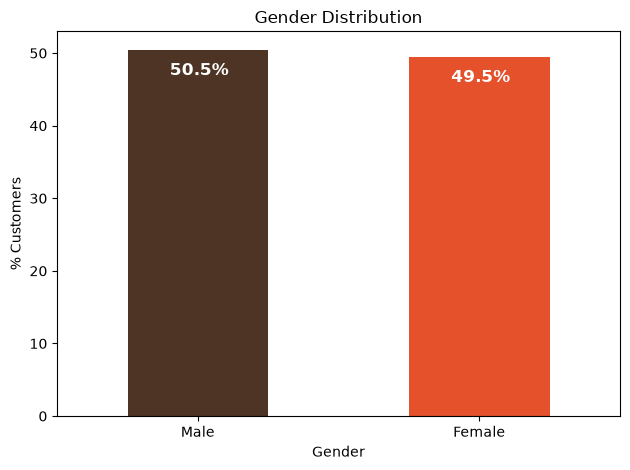

In [14]:
colors = ['#4D3425','#E4512B']
ax = (df['gender'].value_counts()*100.0 /len(df)).plot(kind='bar',
                                                                           stacked = True,
                                                                          rot = 0,
                                                                          color = colors)

ax.set_ylabel('% Customers')
ax.set_xlabel('Gender')
ax.set_ylabel('% Customers')
ax.set_title('Gender Distribution')


totals = []

for i in ax.patches:
    totals.append(i.get_width())


total = sum(totals)

for i in ax.patches:

    ax.text(i.get_x()+.15, i.get_height()-3.5, \
            str(round((i.get_height()/total), 1))+'%',
            fontsize=12,
            color='white',
           weight = 'bold')

plt.tight_layout()
plt.show()

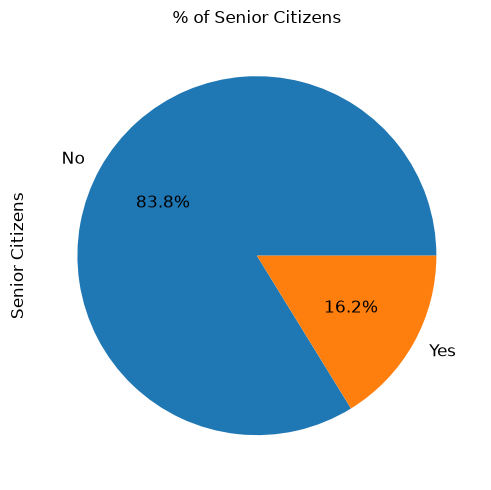

In [15]:
ax = (df['SeniorCitizen'].value_counts()*100.0 /len(df)).plot.pie(autopct='%.1f%%', labels = ['No', 'Yes'],figsize =(5,5), fontsize = 12 )                                                                           

ax.set_ylabel('Senior Citizens',fontsize = 12)
ax.set_title('% of Senior Citizens', fontsize = 12)

plt.tight_layout()
plt.show()

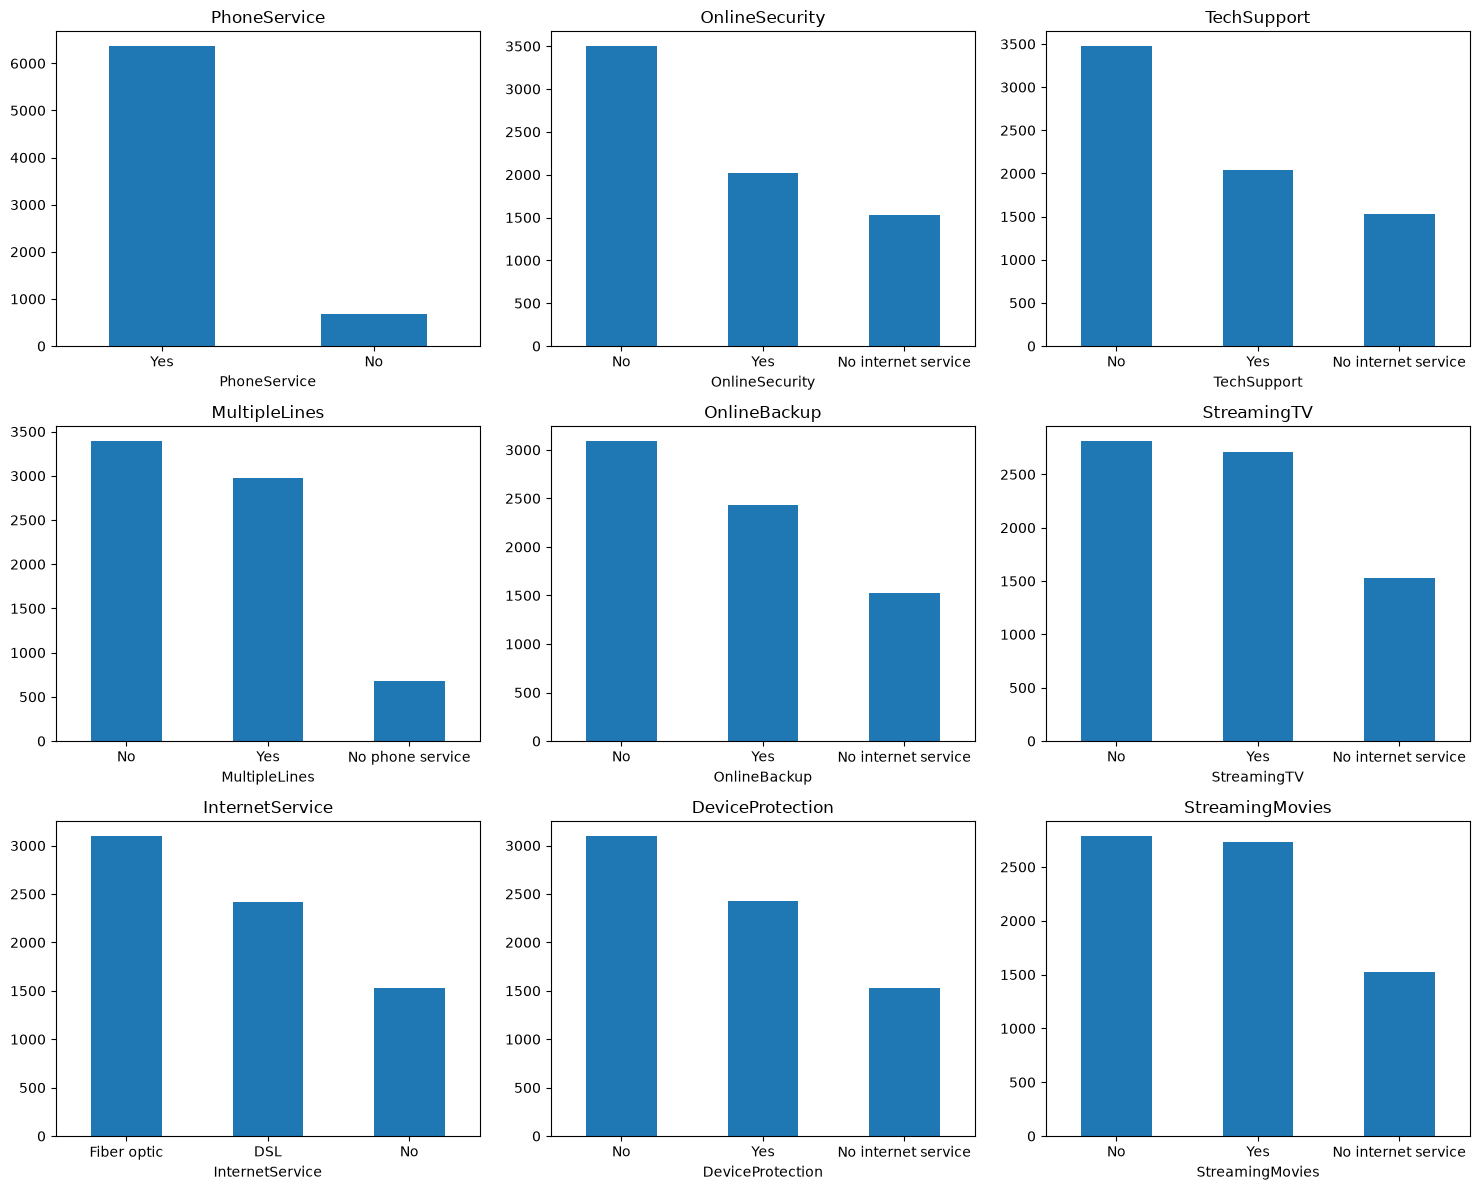

In [16]:
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,12))
for i, item in enumerate(services):
    if i < 3:
        ax = df[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0)
        
    elif i >=3 and i < 6:
        ax = df[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1],rot = 0)
        
    elif i < 9:
        ax = df[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0)
    ax.set_title(item)
plt.tight_layout()
plt.show()

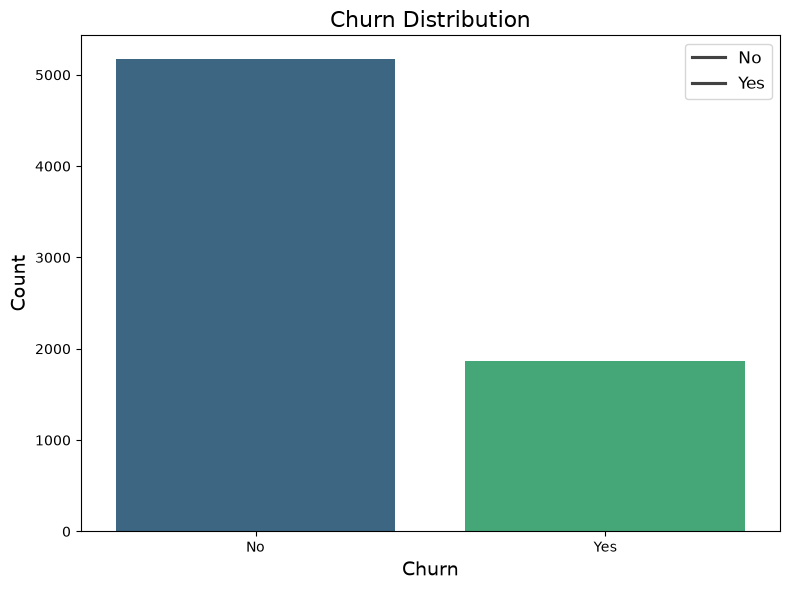

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

ax = sns.barplot(x=df['Churn'].value_counts().index, y=df['Churn'].value_counts().values, hue=df['Churn'].value_counts().index, palette='viridis', legend=False)    
plt.title('Churn Distribution', fontsize=16)
plt.xlabel('Churn', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.legend(['No', 'Yes'], loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()

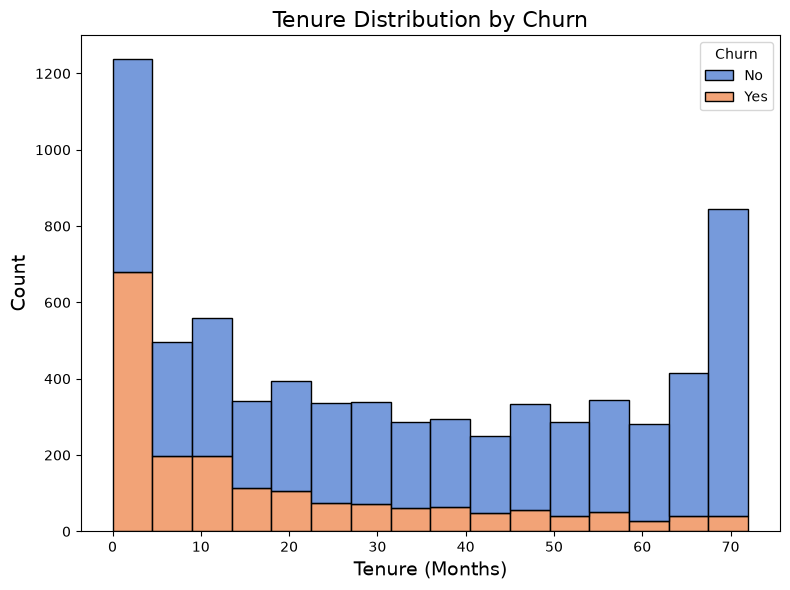

In [18]:
plt.figure(figsize=(8, 6))

ax = sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='muted')
plt.title('Tenure Distribution by Churn', fontsize=16)
plt.xlabel('Tenure (Months)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()


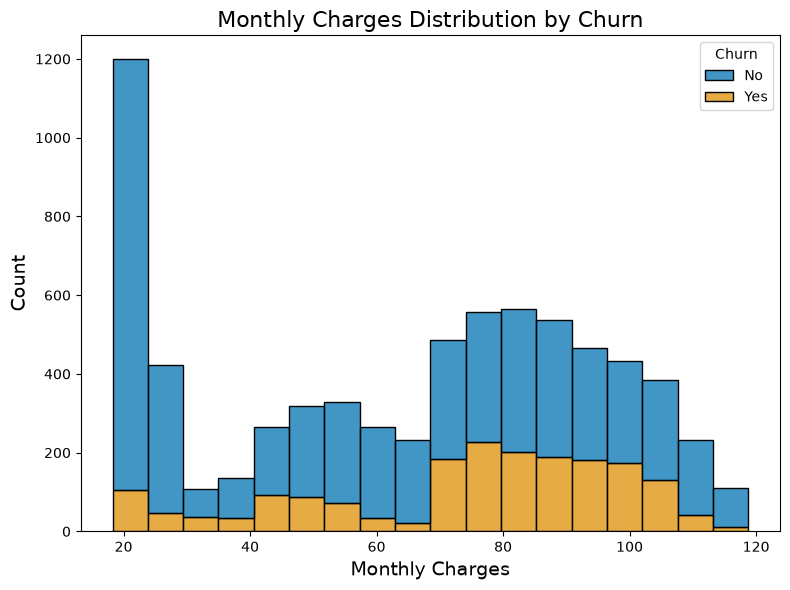

In [19]:
plt.figure(figsize=(8, 6))

ax = sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', palette='colorblind')
plt.title('Monthly Charges Distribution by Churn', fontsize=16) 
plt.xlabel('Monthly Charges', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()


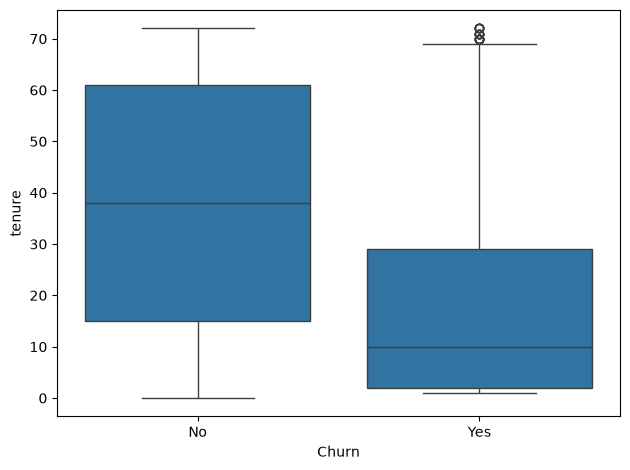

In [20]:
sns.boxplot(x = df.Churn, y = df.tenure)

plt.tight_layout()
plt.show()

# Preprocessing

Our data seems to clean and there is no missing values. We need to preprocess the categorical values. For those having 0 and 1 we shall do the binary encoding and some are having the 4 values we will be doing one hot encoding.

# Binary Encoding

In [21]:
single_cols = [col for col in df.columns if df[col].nunique() ==2 ]
mapping = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}
df[single_cols] = df[single_cols].replace(mapping).astype(int)

In [22]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,0,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,0,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,0,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,1,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


# One-Hot Encoding 

In [23]:
multi_cols = [col for col in df.columns if 2 < df[col].nunique() <=4]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,56.95,1889.50,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [25]:
bool_cols = [col for col in df.columns if df[col].dtypes == 'bool']
df[bool_cols] = df[bool_cols].astype(int)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  MultipleLines_Y

# Correlation Matrix

In [27]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                    1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService                             0.011942
gender                                   0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner                                 -0.150448
Dependents                              -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


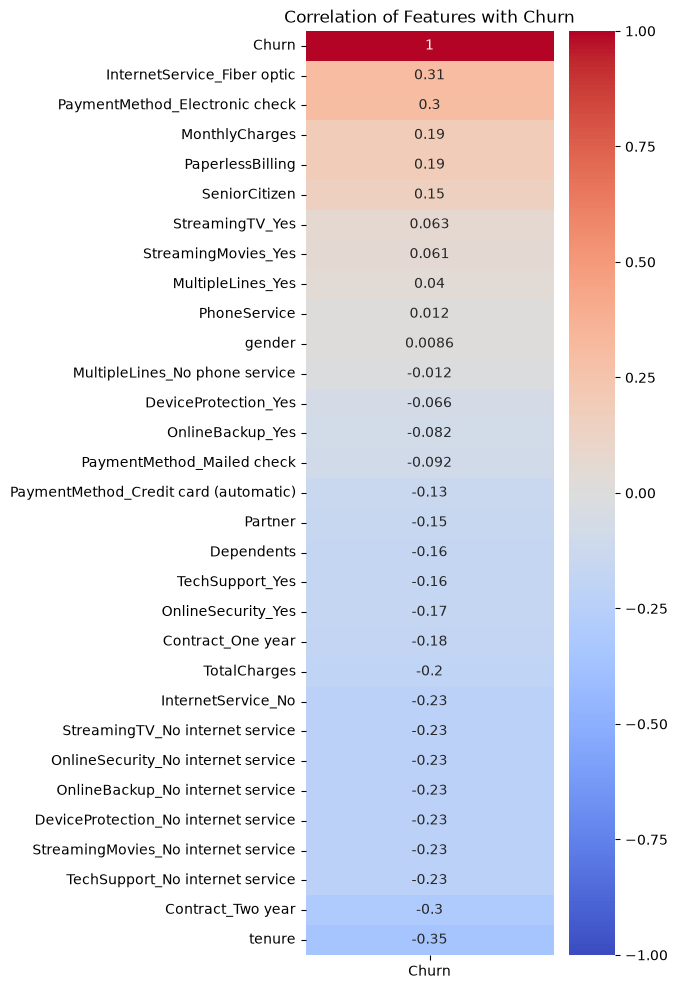

In [28]:
corr_matrix = df.corr(numeric_only=True)

churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

From this correlation map we can conclude that the customer who stays long are having less possibility of churn. So the customer with long term contracts and tenure is high is having negative correlation. 

Fiber optic users is having the most probability of churn in this dataset and other category is the Customers paying electronically. 

# Multicollinearity Check (VIF)

We need to combine the "No internet service" columns into a single column to avoid redundancy. We will create a new column called 'No_internet_service' that will be 1 if any of the related services have "No internet service" and 0 otherwise.


In [29]:
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)


drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)


if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [30]:
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [31]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

f:\Samith\Github\Customer-Churn-Guard\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1775.269077
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.934666
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

We can see that there's multicolinearity between features. So we remove duplicate or complementary features and try tree-based models (Random Forest, XGBoost, LightGBM, CatBoost) which are less sensitive to multicollinearity. 

In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

We need to check two columns and decide whether to remove or not. 'InternetService_No' and 'No_internet_service' seems identical so we need to remove 1 column. Also there is 'PhoneService' column which is just opposite of 'No_phone_service' and we need to keep only 1 column. 

In [32]:
df2 = df[['InternetService_No','No_internet_service', 'PhoneService', 'No_phone_service']]
df2.head()

,InternetService_No,No_internet_service,PhoneService,No_phone_service
0,0,0,0,1
1,0,0,1,0
2,0,0,1,0
3,0,0,0,1
4,0,0,1,0


In [33]:
df['InternetService_No'].equals(df['No_internet_service'])

True

In [34]:
df['PhoneService'].value_counts()

PhoneService
1    6361
0     682
Name: count, dtype: int64

In [35]:
df['No_phone_service'].value_counts()

No_phone_service
0    6361
1     682
Name: count, dtype: int64

In [36]:
df.drop(columns=["InternetService_No","No_phone_service"], inplace=True)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  InternetService

In [38]:
df.to_csv(r'F:\Samith\Github\Customer-Churn-Guard\data\processed_data\telco_churn_processed.csv', index=False)

# Model Training 

Before moving to model training we will check whether there is any class imbalance. 

In [39]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

The imbalance ratio is approximately 2.77 : 1.

This is only a moderate class imbalance, not a severe one. No need to immediately apply SMOTE or undersampling, but for this dataset that's often unnecessary and can even reduce performance.

Let's build the baseline models and then compare its performance then if needed only will apply SMOTE or undersampling. Most probably it not needed. 

In [40]:
from sklearn.model_selection import train_test_split
import time
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score




In [41]:
# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3

In [42]:
def threshold_metrics(y_test, proba, threshold=THRESHOLD):
    for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
        preds = (proba >= thresh).astype(int)
        prec = precision_score(y_test, preds, pos_label=1)
        rec = recall_score(y_test, preds, pos_label=1)
        f1 = f1_score(y_test, preds, pos_label=1)
        print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

### RandomForest Classifier

In [43]:


rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.929     0.659     0.771      1035
           1      0.477     0.861     0.614       374

    accuracy                          0.713      1409
   macro avg      0.703     0.760     0.692      1409
weighted avg      0.809     0.713     0.729      1409



In [44]:


proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
threshold_metrics(y_test, proba, threshold=THRESHOLD)


Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.448   0.888   0.596   
0.3     0.477   0.861   0.614   
0.35    0.495   0.805   0.613   
0.4     0.510   0.757   0.609   
0.45    0.531   0.695   0.602   
0.5     0.556   0.650   0.599   


### XGBoost Classifier

In [45]:



scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 10.94 seconds
⏱ Prediction time: 0.0455 seconds
              precision    recall  f1-score   support

           0      0.909     0.686     0.782      1035
           1      0.482     0.810     0.605       374

    accuracy                          0.719      1409
   macro avg      0.696     0.748     0.693      1409
weighted avg      0.796     0.719     0.735      1409



In [46]:

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
threshold_metrics(y_test, proba, threshold=THRESHOLD)

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.470   0.842   0.603   
0.3     0.482   0.810   0.605   
0.35    0.502   0.783   0.612   
0.4     0.517   0.762   0.616   
0.45    0.534   0.741   0.620   
0.5     0.547   0.706   0.616   


### LightGBM classifier

In [47]:


lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 6.10 seconds
⏱ Prediction time: 0.0697 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.73

In [48]:


proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
threshold_metrics(y_test, proba, threshold=THRESHOLD)

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   


# CatBoost Classifier 

In [49]:
cat = CatBoostClassifier(
    iterations=500,               
    learning_rate=0.05,
    random_seed=42,               
    verbose=100                   
)

# Training timer
start_train = time.time()
cat.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = cat.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

0:	learn: 0.6643208	total: 128ms	remaining: 1m 3s
100:	learn: 0.3798043	total: 2.1s	remaining: 8.29s
200:	learn: 0.3520317	total: 4.35s	remaining: 6.47s
300:	learn: 0.3250154	total: 6.37s	remaining: 4.21s
400:	learn: 0.3030258	total: 8.97s	remaining: 2.21s
499:	learn: 0.2841925	total: 11.1s	remaining: 0us
⏱ Training time: 11.73 seconds
⏱ Prediction time: 0.0217 seconds
              precision    recall  f1-score   support

           0      0.891     0.773     0.828      1035
           1      0.540     0.738     0.624       374

    accuracy                          0.764      1409
   macro avg      0.715     0.755     0.726      1409
weighted avg      0.798     0.764     0.774      1409



In [50]:
proba = cat.predict_proba(X_test)[:, 1]

print("Threshold tuning for CatBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
threshold_metrics(y_test, proba, threshold=THRESHOLD)

Threshold tuning for CatBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.512   0.786   0.620   
0.3     0.540   0.738   0.624   
0.35    0.552   0.682   0.610   
0.4     0.574   0.620   0.596   
0.45    0.616   0.588   0.602   
0.5     0.648   0.527   0.581   


Customer churn prediction requires balancing precision and recall because false positives increase retention costs, while false negatives represent lost customers. LightGBM and CatBoost already demonstrated strong baseline performance, so hyperparameter optimization need to be performed to improve this trade-off rather than simply increasing accuracy.

## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [58]:
import time
import numpy as np
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import precision_recall_curve, classification_report


def best_f1_and_threshold(y_true, proba):
    """Return the best achievable F1 (for class 1) and the threshold that gives it."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1s = 2 * precision * recall / (precision + recall + 1e-9)
    f1s = f1s[:-1]  
    best_idx = np.argmax(f1s)
    return f1s[best_idx], thresholds[best_idx]


def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1000),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 10),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "Logloss",
        "auto_class_weights": "Balanced",
        "random_state": 42,
        "verbose": 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_val)[:, 1]
        fold_best_f1, _ = best_f1_and_threshold(y_val, proba)
        f1_scores.append(fold_best_f1)

    return np.mean(f1_scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("=" * 50)
print("Best CV F1 (per-fold optimal threshold):", study.best_value)
print("Best Params:", study.best_params)





[I 2026-08-02 23:38:46,227] A new study created in memory with name: no-name-be7ed627-9a34-497f-b882-a889e085236f
Best trial: 0. Best value: 0.639365:   2%|▎         | 1/40 [00:34<22:20, 34.37s/it]

[I 2026-08-02 23:39:20,608] Trial 0 finished with value: 0.639365053074685 and parameters: {'iterations': 416, 'depth': 6, 'learning_rate': 0.04960250745589692, 'l2_leaf_reg': 8.973108278619131, 'bagging_temperature': 7.2377692742192625, 'random_strength': 8.302083896781221, 'border_count': 183}. Best is trial 0 with value: 0.639365053074685.


Best trial: 0. Best value: 0.639365:   5%|▌         | 2/40 [01:43<34:33, 54.55s/it]

[I 2026-08-02 23:40:29,282] Trial 1 finished with value: 0.6086474661131579 and parameters: {'iterations': 958, 'depth': 5, 'learning_rate': 0.12125890128251761, 'l2_leaf_reg': 5.37367674142907, 'bagging_temperature': 0.1899365186078572, 'random_strength': 3.3318033157017495, 'border_count': 192}. Best is trial 0 with value: 0.639365053074685.


Best trial: 0. Best value: 0.639365:   8%|▊         | 3/40 [02:39<34:16, 55.57s/it]

...

[I 2026-08-03 00:18:30,756] Trial 37 finished with value: 0.6483696479940662 and parameters: {'iterations': 621, 'depth': 4, 'learning_rate': 0.016491237882784105, 'l2_leaf_reg': 9.197651960132449, 'bagging_temperature': 8.881133405624917, 'random_strength': 2.537720700001909, 'border_count': 180}. Best is trial 32 with value: 0.6509404486649347.


Best trial: 32. Best value: 0.65094:  98%|█████████▊| 39/40 [40:19<00:36, 36.79s/it]

[I 2026-08-03 00:19:05,624] Trial 38 finished with value: 0.649628405367667 and parameters: {'iterations': 486, 'depth': 5, 'learning_rate': 0.013086958132103903, 'l2_leaf_reg': 6.631294320408269, 'bagging_temperature': 7.856351986227312, 'random_strength': 3.5898391672573386, 'border_count': 233}. Best is trial 32 with value: 0.6509404486649347.


Best trial: 32. Best value: 0.65094: 100%|██████████| 40/40 [40:51<00:00, 61.29s/it]

[I 2026-08-03 00:19:37,920] Trial 39 finished with value: 0.6465766536833446 and parameters: {'iterations': 462, 'depth': 5, 'learning_rate': 0.010676215679211285, 'l2_leaf_reg': 6.641610701058866, 'bagging_temperature': 5.564546690905674, 'random_strength': 3.8616462266251186, 'border_count': 235}. Best is trial 32 with value: 0.6509404486649347.
Best CV F1 (per-fold optimal threshold): 0.6509404486649347
Best Params: {'iterations': 526, 'depth': 4, 'learning_rate': 0.01558978417396234, 'l2_leaf_reg': 8.37483763026004, 'bagging_temperature': 7.771250956585797, 'random_strength': 1.9949597614815104, 'border_count': 193}


In [59]:

best_params = study.best_params
best_params.update({
    "random_state": 42,
    "auto_class_weights": "Balanced",
    "loss_function": "Logloss",
    "verbose": 0,
})


X_tr_final, X_thresh, y_tr_final, y_thresh = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

model_cat = CatBoostClassifier(**best_params)

start_train = time.time()
model_cat.fit(X_tr_final, y_tr_final)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

thresh_proba = model_cat.predict_proba(X_thresh)[:, 1]
_, THRESHOLD = best_f1_and_threshold(y_thresh, thresh_proba)
print(f"Selected threshold: {THRESHOLD:.4f}")


model_cat = CatBoostClassifier(**best_params)
model_cat.fit(X_train, y_train)

start_pred = time.time()
proba = model_cat.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 6.94 seconds
Selected threshold: 0.6007
⏱ Prediction time: 0.0144 seconds
              precision    recall  f1-score   support

           0      0.878     0.810     0.843      1035
           1      0.567     0.690     0.622       374

    accuracy                          0.778      1409
   macro avg      0.723     0.750     0.733      1409
weighted avg      0.796     0.778     0.784      1409



In [60]:

from lightgbm import LGBMClassifier


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "objective": "binary",
        "class_weight": "balanced",
        "random_state": 42,
        "verbose": -1,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, valid_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = LGBMClassifier(**params)
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_val)[:, 1]
        fold_best_f1, _ = best_f1_and_threshold(y_val, proba)
        f1_scores.append(fold_best_f1)

    return np.mean(f1_scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("=" * 50)
print("Best CV F1 (per-fold optimal threshold):", study.best_value)
print("Best Params:", study.best_params)



[I 2026-08-03 00:19:52,860] A new study created in memory with name: no-name-f48d9ac2-ec07-4027-be07-fc46a17a2b1c
Best trial: 0. Best value: 0.626693:   2%|▎         | 1/40 [00:15<10:03, 15.48s/it]

[I 2026-08-03 00:20:08,341] Trial 0 finished with value: 0.6266931710244513 and parameters: {'n_estimators': 679, 'max_depth': 6, 'num_leaves': 125, 'learning_rate': 0.05397964191081443, 'min_child_samples': 32, 'subsample': 0.8589196809448443, 'colsample_bytree': 0.7130966726016997, 'reg_alpha': 0.0029035185175370366, 'reg_lambda': 1.2595466122322374}. Best is trial 0 with value: 0.6266931710244513.


Best trial: 0. Best value: 0.626693:   5%|▌         | 2/40 [00:24<07:15, 11.47s/it]

[I 2026-08-03 00:20:16,997] Trial 1 finished with value: 0.6220600742188983 and parameters: {'n_estimators': 802, 'max_depth': 6, 'num_leaves': 155, 'learning_rate': 0.11770271093245371, 'min_child_samples': 22, 'subsample': 0.5845711914918592, 'colsample_bytree': 0.8300315390578539, 'reg_alpha': 1.1643723903953664, 'reg_lambda': 0.001515706430316948}. Best is trial 0 with value: 0.6266931710244513.


Best trial: 2. Best value: 0.630743:   8%|▊         | 3/40 [00:34<06:45, 10.97s/it]

...

[I 2026-08-03 00:26:08,210] Trial 37 finished with value: 0.6410784573128666 and parameters: {'n_estimators': 786, 'max_depth': 4, 'num_leaves': 209, 'learning_rate': 0.011026465918619353, 'min_child_samples': 65, 'subsample': 0.8614686478922449, 'colsample_bytree': 0.9591735329769536, 'reg_alpha': 0.009234987278183305, 'reg_lambda': 0.00420536905399203}. Best is trial 15 with value: 0.6470607196745355.


Best trial: 15. Best value: 0.647061:  98%|█████████▊| 39/40 [06:22<00:08,  8.96s/it]

[I 2026-08-03 00:26:15,170] Trial 38 finished with value: 0.6441931481333063 and parameters: {'n_estimators': 916, 'max_depth': 5, 'num_leaves': 163, 'learning_rate': 0.0604118691987857, 'min_child_samples': 15, 'subsample': 0.7858780114855551, 'colsample_bytree': 0.8170181171958724, 'reg_alpha': 6.727737000550465, 'reg_lambda': 0.013354995902654038}. Best is trial 15 with value: 0.6470607196745355.


Best trial: 15. Best value: 0.647061: 100%|██████████| 40/40 [06:28<00:00,  9.71s/it]

[I 2026-08-03 00:26:21,401] Trial 39 finished with value: 0.631235560436072 and parameters: {'n_estimators': 657, 'max_depth': 6, 'num_leaves': 146, 'learning_rate': 0.14925679109888065, 'min_child_samples': 49, 'subsample': 0.927647196137646, 'colsample_bytree': 0.8719676668987401, 'reg_alpha': 1.8982625422326291, 'reg_lambda': 0.03659122384518086}. Best is trial 15 with value: 0.6470607196745355.
Best CV F1 (per-fold optimal threshold): 0.6470607196745355
Best Params: {'n_estimators': 895, 'max_depth': 4, 'num_leaves': 72, 'learning_rate': 0.142229619602883, 'min_child_samples': 6, 'subsample': 0.8089161508086422, 'colsample_bytree': 0.7908220432076243, 'reg_alpha': 8.34792893610425, 'reg_lambda': 0.009691109153133004}


In [61]:

best_params = study.best_params
best_params.update({
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42,
    "verbose": -1,
})


X_tr_final, X_thresh, y_tr_final, y_thresh = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

model_lgbm = LGBMClassifier(**best_params)

start_train = time.time()
model_lgbm.fit(X_tr_final, y_tr_final)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

thresh_proba = model_lgbm.predict_proba(X_thresh)[:, 1]
_, THRESHOLD = best_f1_and_threshold(y_thresh, thresh_proba)
print(f"Selected threshold: {THRESHOLD:.4f}")

# Refit on full X_train now that threshold is fixed
model_lgbm = LGBMClassifier(**best_params)
model_lgbm.fit(X_train, y_train)

start_pred = time.time()
proba = model_lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.86 seconds
Selected threshold: 0.5998
⏱ Prediction time: 0.0184 seconds
              precision    recall  f1-score   support

           0      0.886     0.806     0.844      1035
           1      0.571     0.714     0.634       374

    accuracy                          0.781      1409
   macro avg      0.728     0.760     0.739      1409
weighted avg      0.802     0.781     0.788      1409



CatBoost and LightGBM — were tuned using Optuna over 5-fold stratified cross-validation, with the decision threshold optimized per fold (rather than fixed) to ensure a fair comparison of each model's true discriminative ability, independent of arbitrary threshold choice. Both final models were evaluated on a held-out test set using a threshold selected from a separate validation split.

LightGBM was selected as the final model based on the following:

- **Better predictive performance on the churn class:** LightGBM achieved a higher F1-score (0.634 vs. 0.622), driven primarily by improved recall (0.714 vs. 0.690) at comparable precision (0.571 vs. 0.567). Since correctly identifying churners is the primary business objective, this improvement in recall — without sacrificing precision — directly translates to catching more at-risk customers without a proportional increase in false alarms.
- **Stronger overall generalization:** LightGBM also produced a higher macro F1 (0.739 vs. 0.733) and overall accuracy (0.781 vs. 0.778), indicating it performs more consistently across both classes rather than trading off one class for the other.
- **Substantially lower training cost:** LightGBM trained roughly 8x faster than CatBoost (0.86s vs. 6.94s) on this dataset. While both are fast in absolute terms at this data scale, this efficiency gap becomes meaningful for retraining cadence, hyperparameter search iteration, and future scaling to larger datasets.
- **Comparable inference latency:** Both models produce predictions in well under 20ms per batch on the test set, so prediction speed was not a differentiating factor at this scale.

Given the marginal but consistent edge in predictive metrics and the significant advantage in training efficiency, LightGBM was chosen as the production model for this churn prediction task.